In [5]:
%pip install numpy pandas matplotlib seaborn scikit-learn xgboost

Defaulting to user installation because normal site-packages is not writeable
  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   - -----------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\TransOrg\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
file_path = r'C:\Users\TransOrg\Desktop\ML-project\Anonymize_Loan_Default_data.csv'
df = pd.read_csv(file_path, encoding='latin1')
 
print("Raw shape:", df.shape)
print("\nFirst 3 rows:")
print(df.head(3))

Raw shape: (38480, 37)

First 3 rows:
   Unnamed: 0      id  member_id  loan_amnt  funded_amnt  funded_amnt_inv  \
0           2       2          2        0.0          0.0              0.0   
1           3  545583     703644     2500.0       2500.0           2500.0   
2           4  532101     687836     5000.0       5000.0           5000.0   

        term  int_rate  installment emp_length  ... total_acc  total_pymnt  \
0  36 months      0.00         0.00   < 1 year  ...       1.0     0.000000   
1  36 months     13.98        85.42    4 years  ...      10.0  3075.291779   
2  36 months     15.95       175.67    4 years  ...      15.0  2948.760000   

  total_pymnt_inv total_rec_prncp total_rec_int last_pymnt_d last_pymnt_amnt  \
0            0.00            0.00          0.00       Jan-07            0.00   
1         3075.29         2500.00        575.29       Jul-13           90.85   
2         2948.76         1909.02        873.81       Nov-11          175.67   

  next_pymnt_d  las

In [3]:
def give_stats(data):
    return data.describe()
 
def give_missing(data):
    return data.isnull().sum()
 
def give_datatype(data):
    return data.dtypes
 
print("Summary Stats:")
print(give_stats(df))
 
print("\nMissing Values (only columns with missing):")
missing = give_missing(df)
print(missing[missing > 0])
 
print("\nData Types:")
print(give_datatype(df))

Summary Stats:
         Unnamed: 0            id     member_id     loan_amnt   funded_amnt  \
count  38480.000000  3.848000e+04  3.848000e+04  38479.000000  38479.000000   
mean   19240.500000  6.649979e+05  8.261899e+05  11094.727644  10831.856337   
std    11108.363516  2.192322e+05  2.793531e+05   7405.416042   7146.853682   
min        1.000000  1.000000e+00  1.000000e+00      0.000000      0.000000   
25%     9620.750000  4.983645e+05  6.384620e+05   5200.000000   5100.000000   
50%    19240.500000  6.443195e+05  8.242545e+05   9750.000000   9600.000000   
75%    28860.250000  8.265608e+05  1.034706e+06  15000.000000  15000.000000   
max    38480.000000  1.077430e+06  1.314167e+06  35000.000000  35000.000000   

       funded_amnt_inv     int_rate   installment    annual_inc           dti  \
count     38479.000000  38480.00000  38479.000000  3.847800e+04  38480.000000   
mean      10150.141518     12.16430    323.163255  6.899531e+04     13.378119   
std        7128.026828      3.

In [4]:
df = df.drop(columns=[
    'Unnamed: 0',
    'id',
    'member_id',
    'loan_status',
    'zip_code',
    'addr_state',
    'next_pymnt_d',
    'mths_since_last_delinq'
])
 
print("Shape after dropping junk columns:", df.shape)
print("Remaining columns:", df.columns.tolist())

Shape after dropping junk columns: (38480, 29)
Remaining columns: ['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'purpose', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'last_pymnt_d', 'last_pymnt_amnt', 'last_credit_pull_d', 'repay_fail']


In [5]:
def parse_revol_util(value):
    if pd.isna(value):
        return np.nan
    numeric = ''.join(filter(str.isdigit, str(value)))
    return int(numeric) / 100 if numeric else np.nan
 
df['revol_util'] = df['revol_util'].apply(parse_revol_util)
 
print("revol_util sample after conversion:")
print(df['revol_util'].head(10).values)
print("Missing in revol_util:", df['revol_util'].isnull().sum())

revol_util sample after conversion:
[ 0.  21.3 99.9 47.2  0.   0.  13.6 47.7 70.8 98.7]
Missing in revol_util: 59


In [6]:
date_columns = ['earliest_cr_line', 'issue_d', 'last_pymnt_d', 'last_credit_pull_d']
 
for col in date_columns:
    df[col] = pd.to_datetime(df[col], format='%b-%y', errors='coerce')
    df[col + '_M'] = df[col].dt.month
    df[col + '_Y'] = df[col].dt.year
 
df = df.drop(columns=date_columns)
 
print("Date columns extracted. New shape:", df.shape)
print(df.info())

Date columns extracted. New shape: (38480, 33)
<class 'pandas.DataFrame'>
RangeIndex: 38480 entries, 0 to 38479
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   loan_amnt             38479 non-null  float64
 1   funded_amnt           38479 non-null  float64
 2   funded_amnt_inv       38479 non-null  float64
 3   term                  38480 non-null  str    
 4   int_rate              38480 non-null  float64
 5   installment           38479 non-null  float64
 6   emp_length            37487 non-null  str    
 7   home_ownership        38480 non-null  str    
 8   annual_inc            38478 non-null  float64
 9   verification_status   38480 non-null  str    
 10  purpose               38480 non-null  str    
 11  dti                   38480 non-null  float64
 12  delinq_2yrs           38479 non-null  float64
 13  inq_last_6mths        38479 non-null  float64
 14  open_acc              38479 non-nu

In [7]:
df['term'] = df['term'].str.extract(r'(\d+)').astype(int)
 
# emp_length: ordinal mapping — "< 1 year" treated as 0.5
emp_length_mapping = {
    '0 year'   : 0,
    '< 1 year' : 0.5,
    '1 year'   : 1,
    '2 years'  : 2,
    '3 years'  : 3,
    '4 years'  : 4,
    '5 years'  : 5,
    '6 years'  : 6,
    '7 years'  : 7,
    '8 years'  : 8,
    '9 years'  : 9,
    '10 years' : 10,
    '10+ years': 11
}
df['emp_length'] = df['emp_length'].map(emp_length_mapping)
 
print("term sample:", df['term'].value_counts().to_dict())
print("emp_length sample:", df['emp_length'].value_counts().to_dict())

term sample: {36: 28593, 60: 9887}
emp_length sample: {11.0: 8465, 0.5: 4565, 2.0: 4292, 3.0: 3939, 4.0: 3314, 1.0: 3254, 5.0: 3171, 6.0: 2144, 7.0: 1702, 8.0: 1445, 9.0: 1196}


In [8]:
categorical_cols = ['home_ownership', 'verification_status', 'purpose']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
 
print("Shape after encoding:", df.shape)
print("String columns remaining (should be empty):",
      df.select_dtypes(include=['object']).columns.tolist())

Shape after encoding: (38480, 49)
String columns remaining (should be empty): []


In [9]:
print("Missing values before dropna:")
print(df.isnull().sum()[df.isnull().sum() > 0])
 
df = df.dropna()
 
print("\nShape after dropna:", df.shape)
print("Class distribution:")
print(df['repay_fail'].value_counts())
print(f"Default rate: {df['repay_fail'].mean():.4%}")

Missing values before dropna:
loan_amnt                 1
funded_amnt               1
funded_amnt_inv           1
installment               1
emp_length              993
annual_inc                2
delinq_2yrs               1
inq_last_6mths            1
open_acc                  1
pub_rec                   1
revol_bal                 4
revol_util               59
total_acc                 1
total_pymnt               1
total_pymnt_inv           1
total_rec_prncp           1
total_rec_int             1
last_pymnt_amnt           1
last_pymnt_d_M           71
last_pymnt_d_Y           71
last_credit_pull_d_M      3
last_credit_pull_d_Y      3
dtype: int64

Shape after dropna: (37359, 49)
Class distribution:
repay_fail
0    31834
1     5525
Name: count, dtype: int64
Default rate: 14.7889%


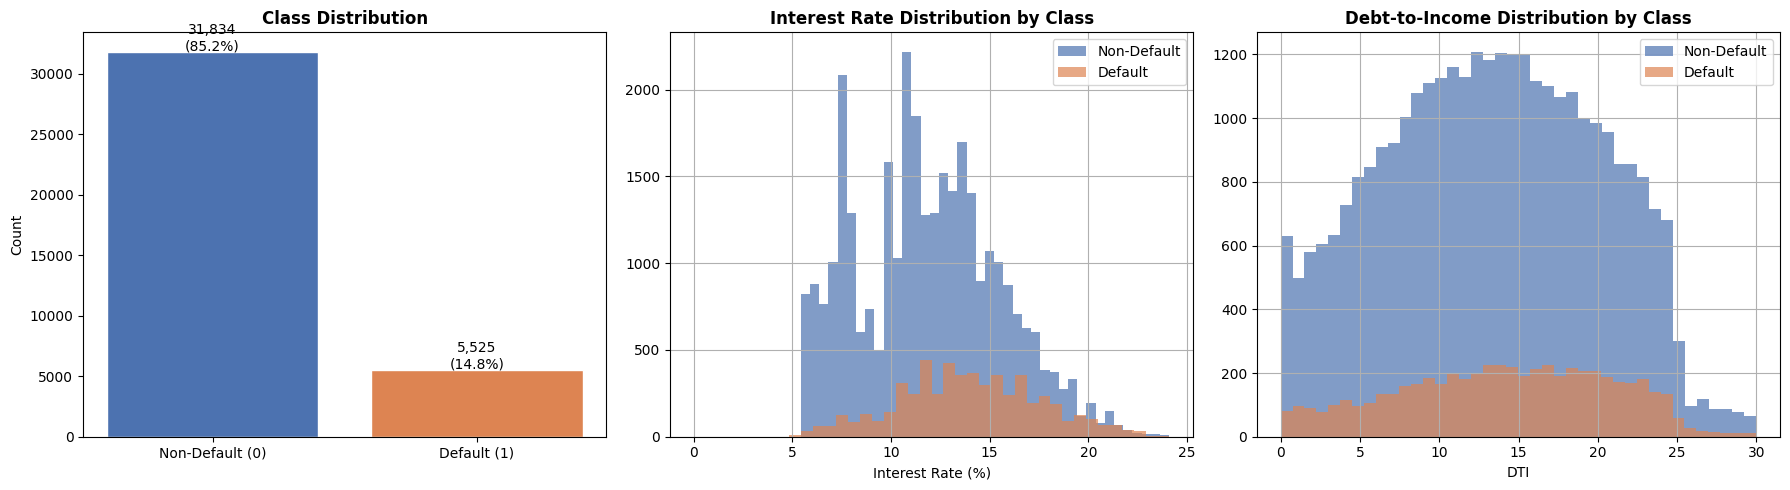

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
# Class imbalance
class_counts = df['repay_fail'].value_counts()
axes[0].bar(['Non-Default (0)', 'Default (1)'],
            class_counts.values,
            color=['#4C72B0', '#DD8452'], edgecolor='white')
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 100, f'{v:,}\n({v/len(df):.1%})', ha='center', fontsize=10)
 
# int_rate by class
df[df['repay_fail'] == 0]['int_rate'].hist(bins=40, ax=axes[1],
    color='#4C72B0', alpha=0.7, label='Non-Default')
df[df['repay_fail'] == 1]['int_rate'].hist(bins=40, ax=axes[1],
    color='#DD8452', alpha=0.7, label='Default')
axes[1].set_title('Interest Rate Distribution by Class', fontweight='bold')
axes[1].set_xlabel('Interest Rate (%)')
axes[1].legend()
 
# dti by class
df[df['repay_fail'] == 0]['dti'].clip(upper=50).hist(bins=40, ax=axes[2],
    color='#4C72B0', alpha=0.7, label='Non-Default')
df[df['repay_fail'] == 1]['dti'].clip(upper=50).hist(bins=40, ax=axes[2],
    color='#DD8452', alpha=0.7, label='Default')
axes[2].set_title('Debt-to-Income Distribution by Class', fontweight='bold')
axes[2].set_xlabel('DTI')
axes[2].legend()
 
plt.tight_layout()
plt.show()

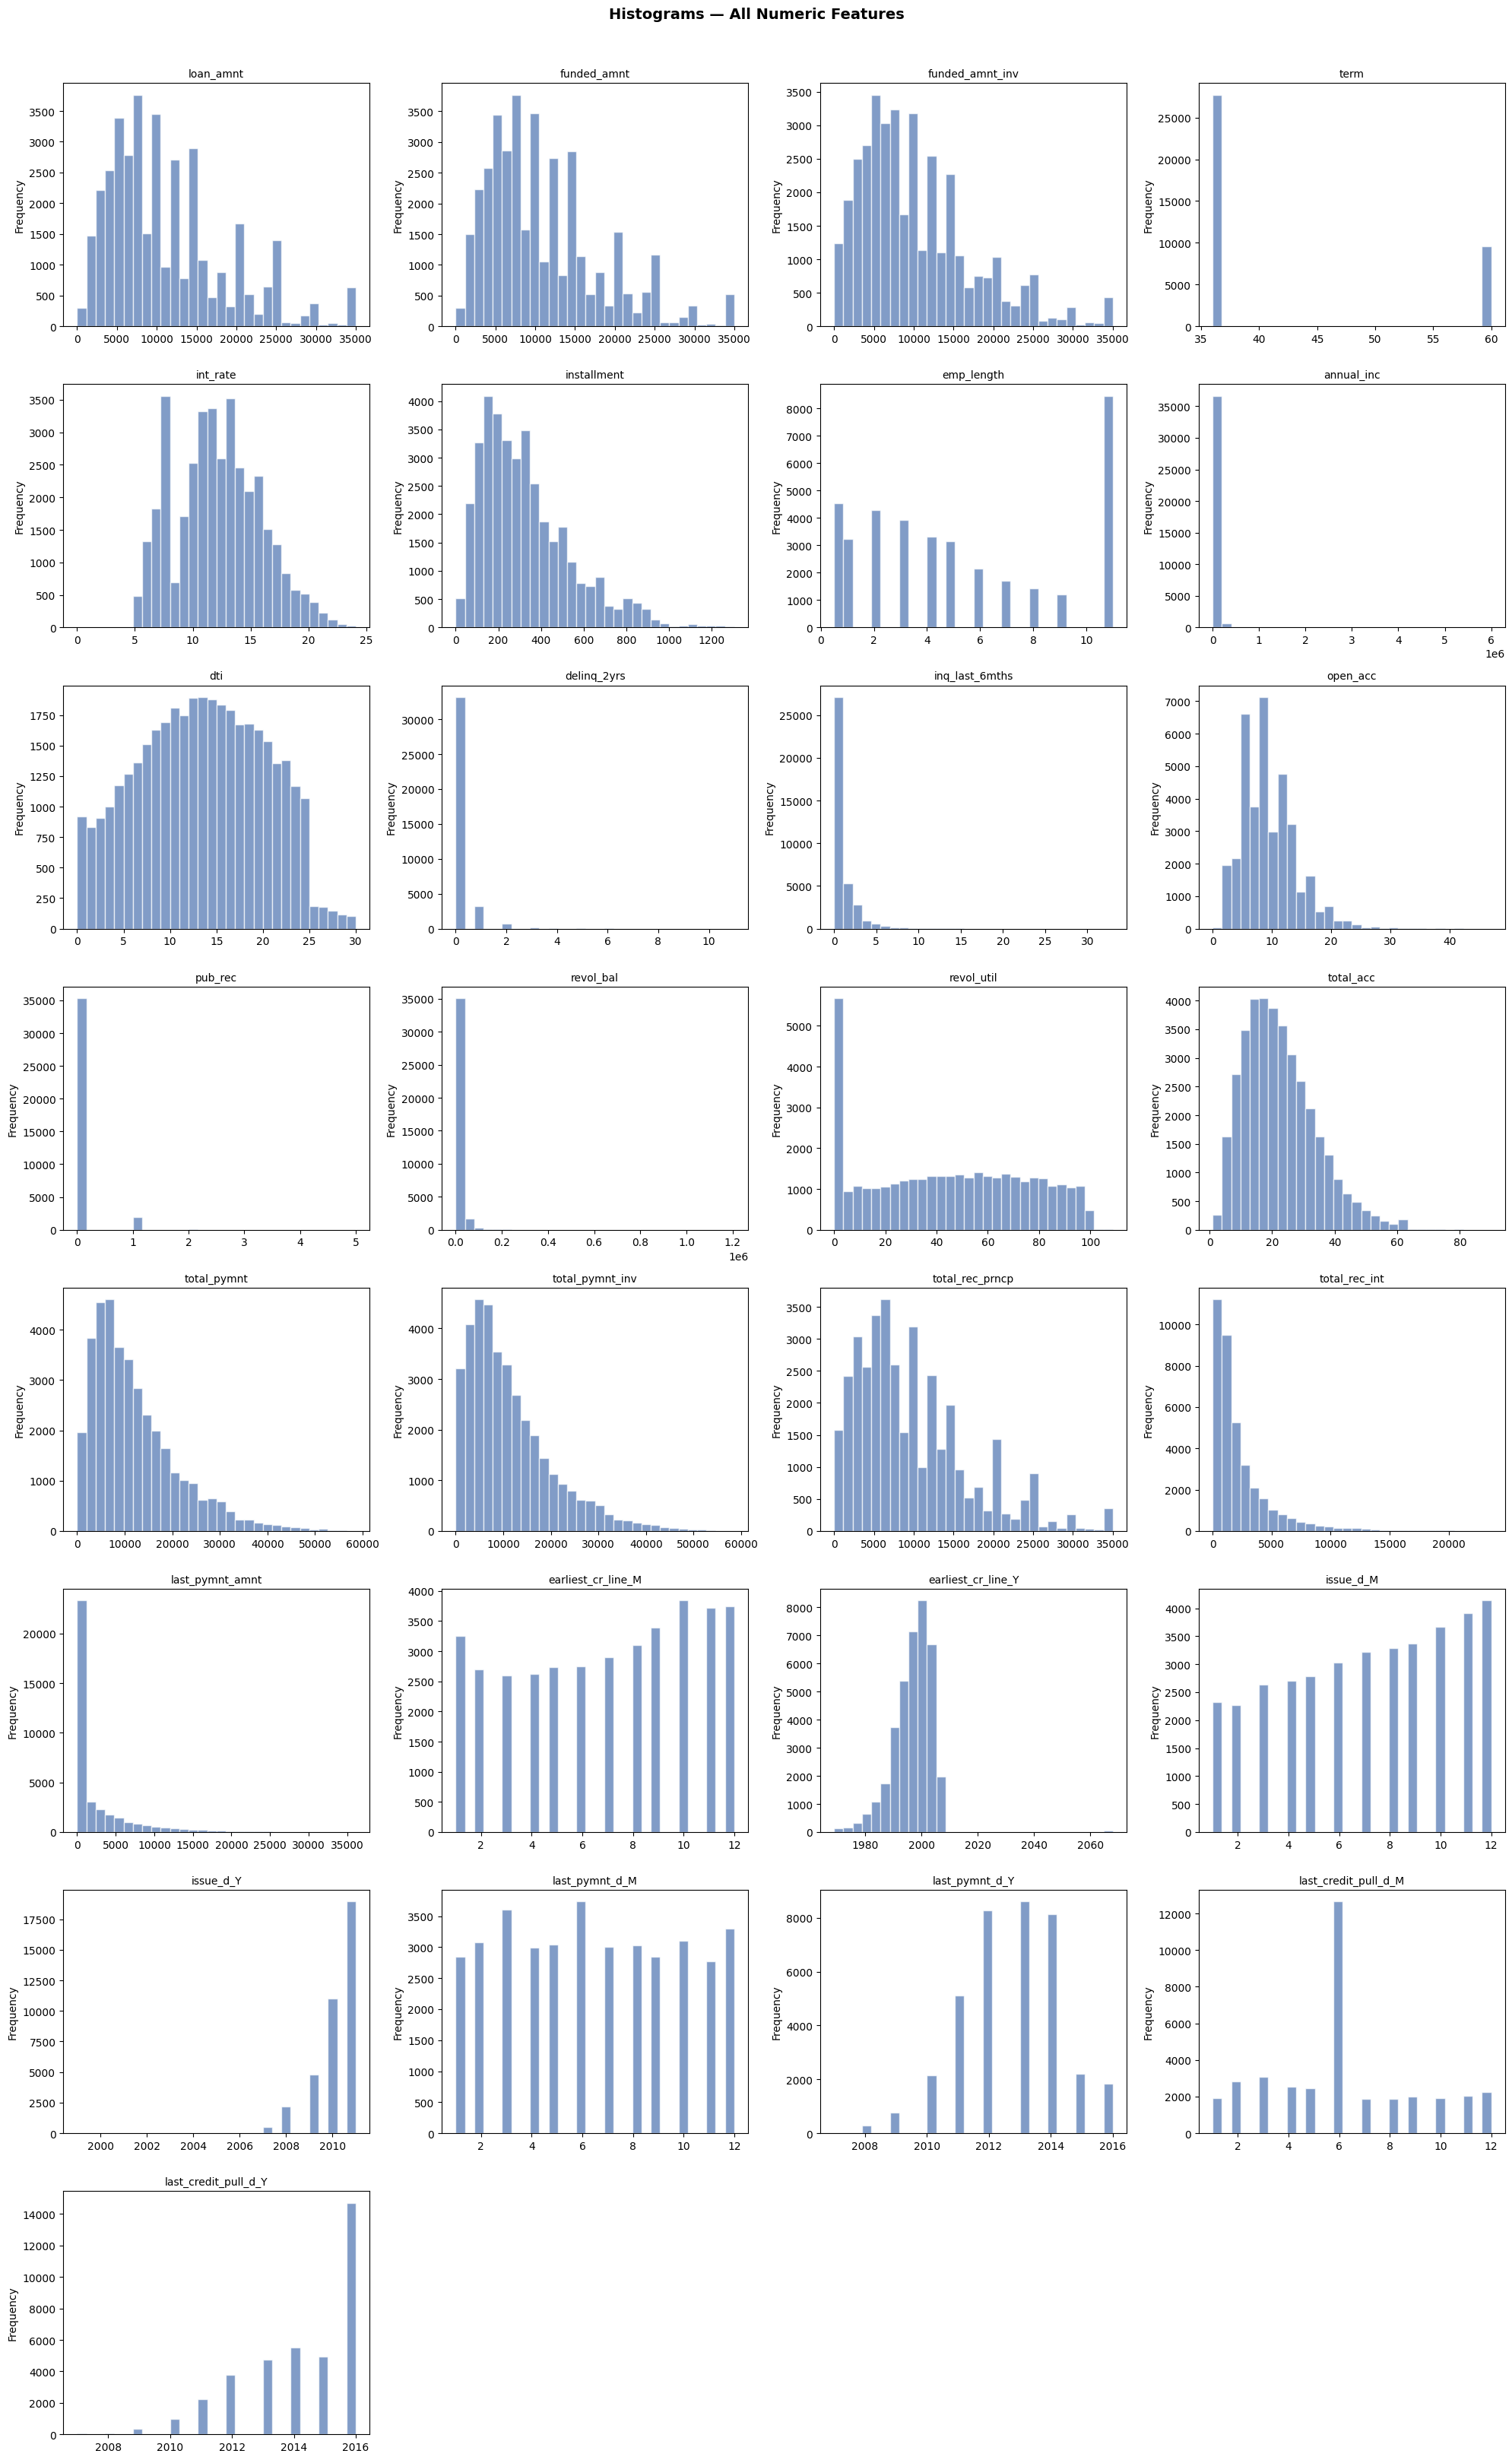

In [11]:
numerical_columns = df.select_dtypes(include=['number']).columns.drop('repay_fail')
 
num_cols_list = list(numerical_columns)
n_cols = 4
n_rows = (len(num_cols_list) + n_cols - 1) // n_cols
 
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()
 
for i, col in enumerate(num_cols_list):
    axes[i].hist(df[col], bins=30, color='#4C72B0', alpha=0.7, edgecolor='white')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('Frequency')
 
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
 
plt.suptitle('Histograms — All Numeric Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

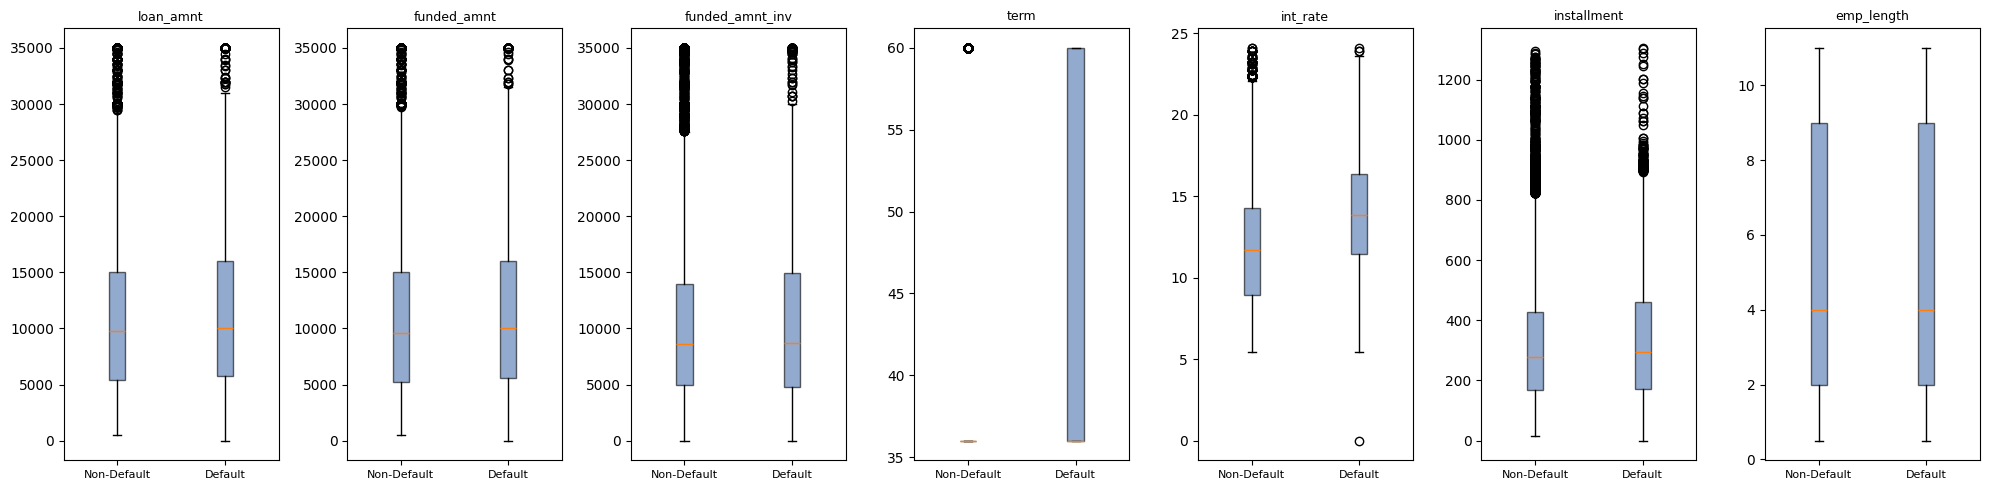

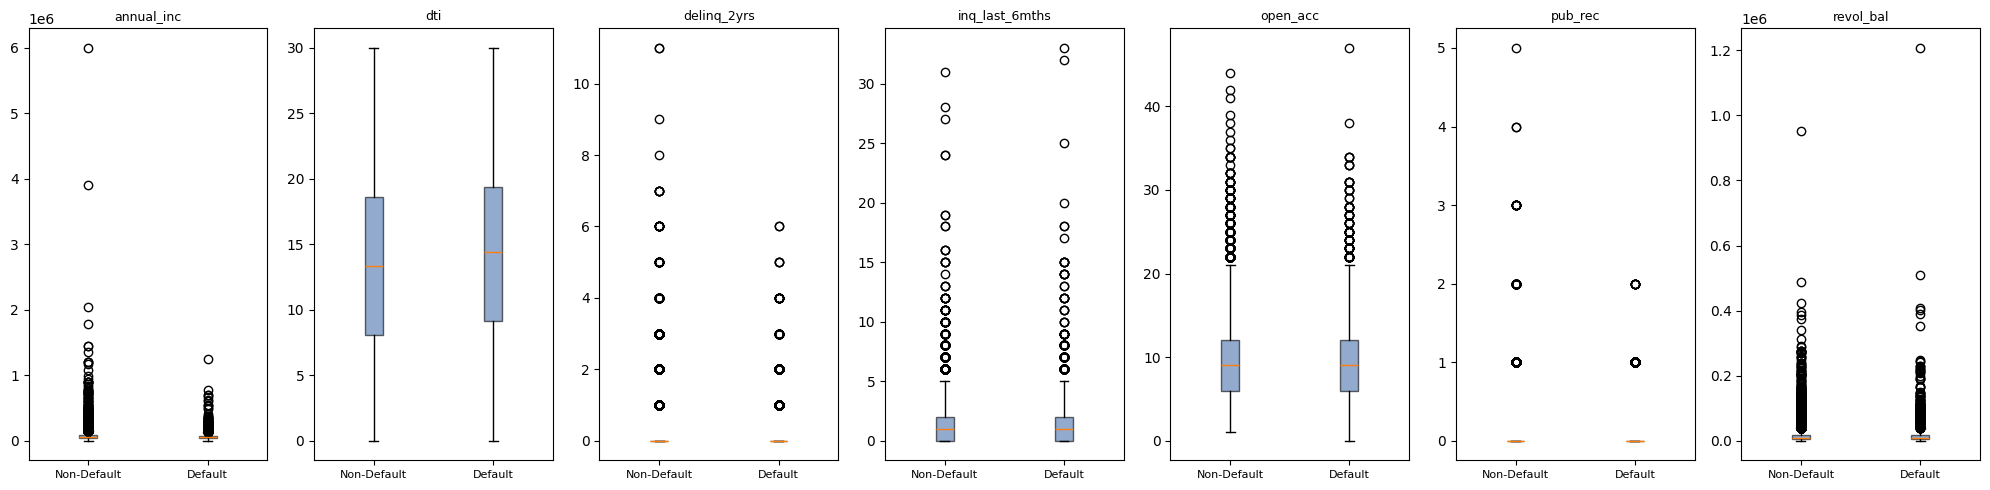

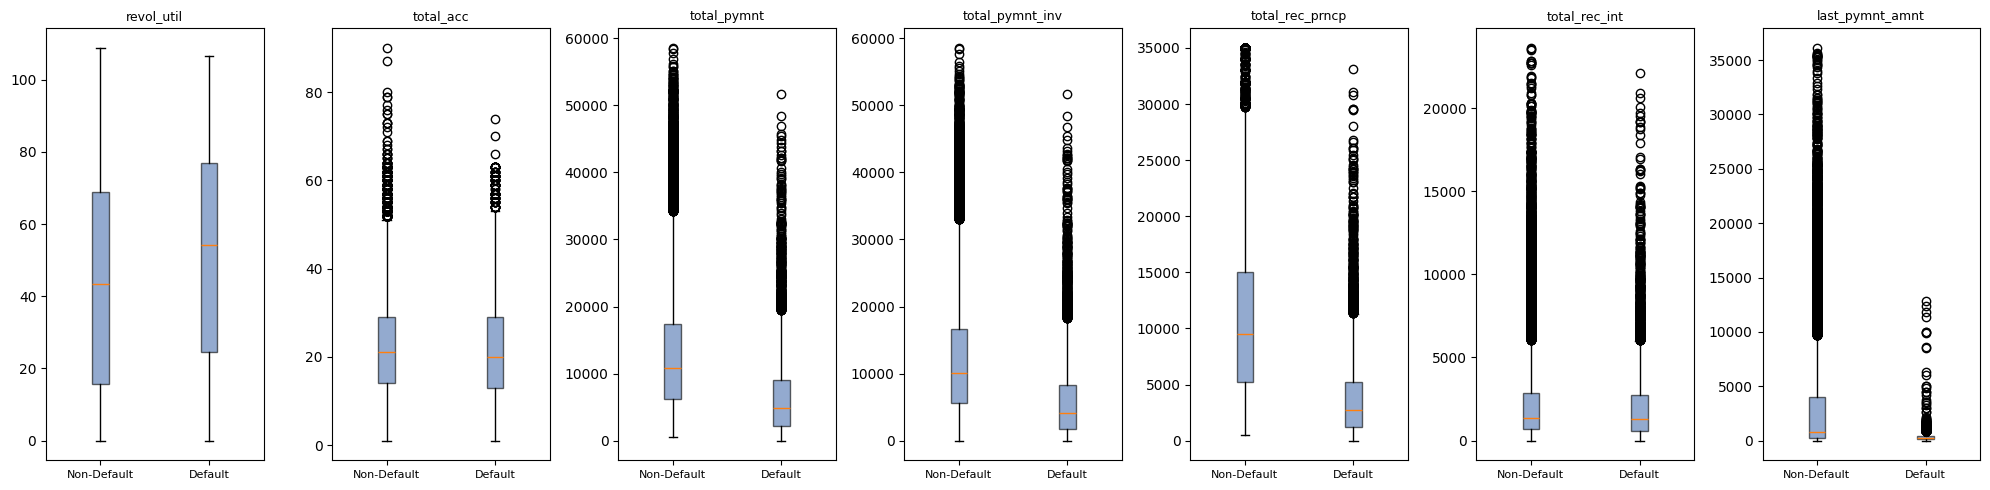

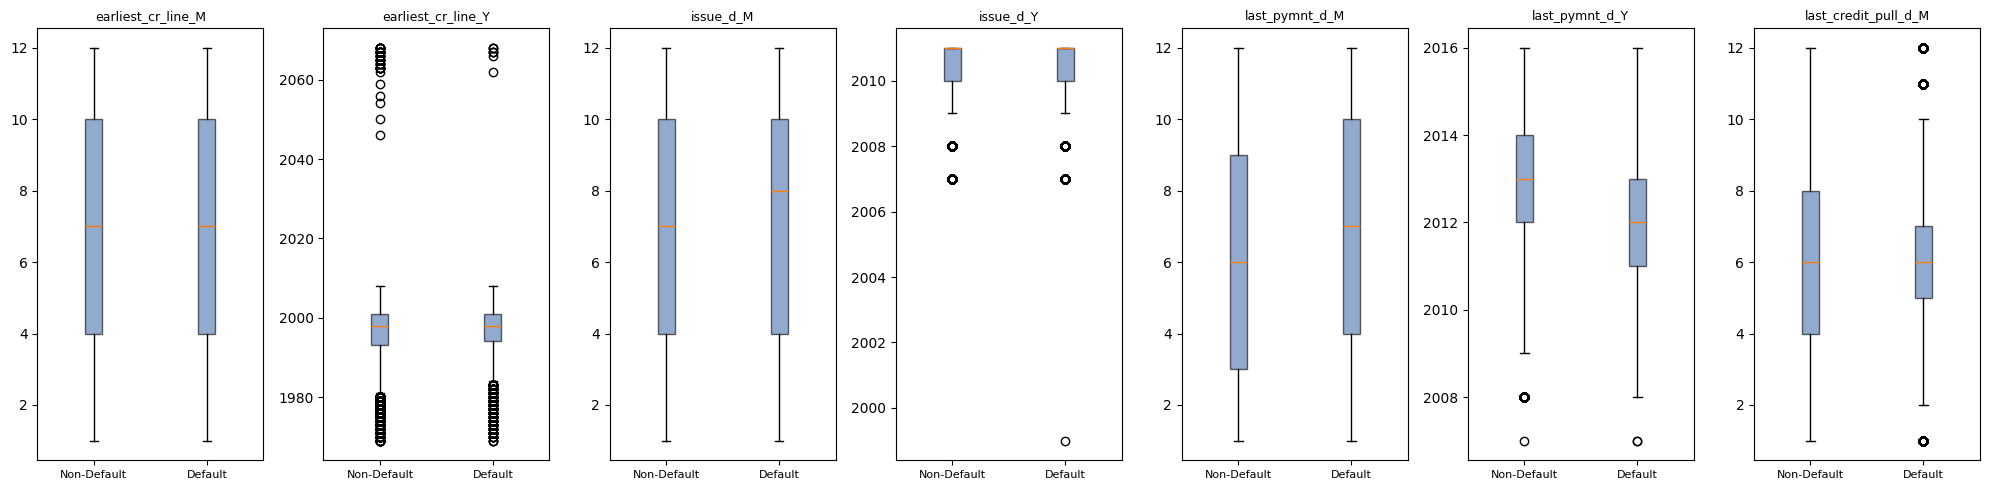

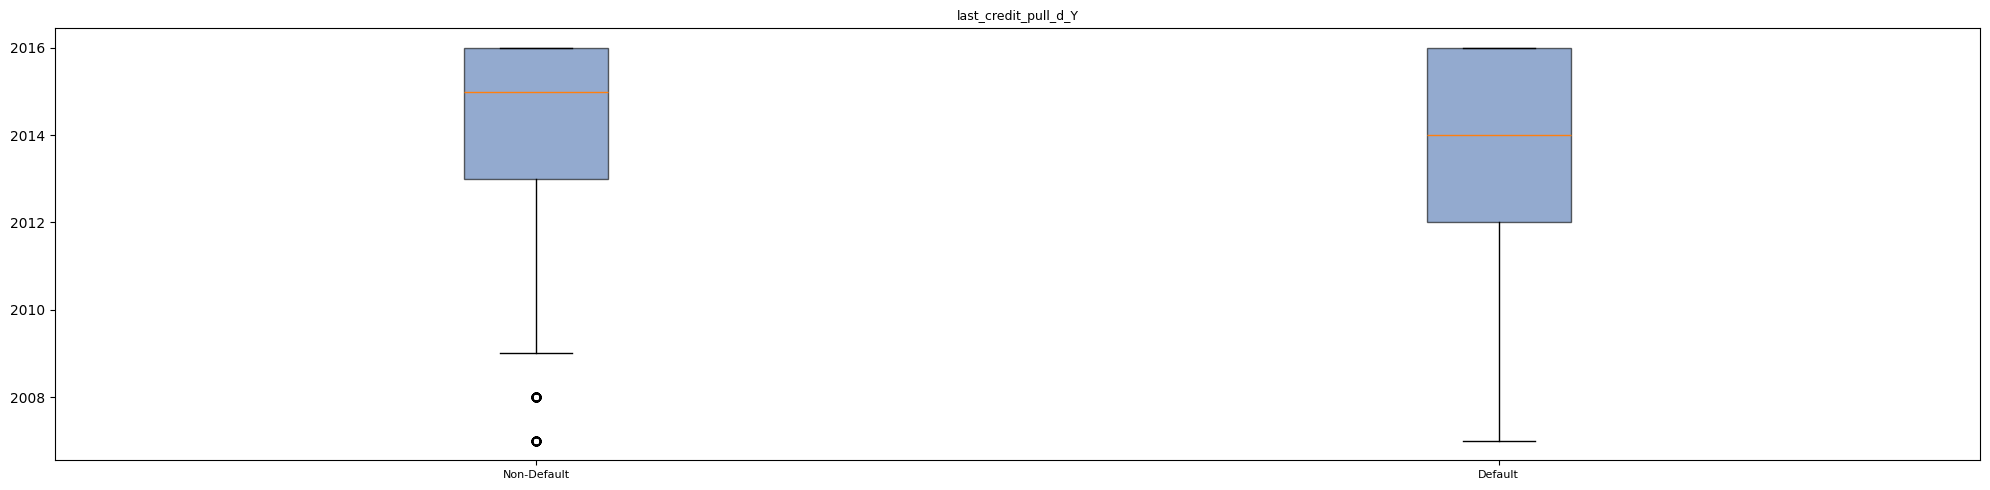

In [12]:
# Split numeric columns into groups of 7 for readable plots
def make_boxplot(ax, column):
    data_0 = df[df['repay_fail'] == 0][column]
    data_1 = df[df['repay_fail'] == 1][column]
    ax.boxplot([data_0, data_1], labels=['Non-Default', 'Default'],
               patch_artist=True,
               boxprops=dict(facecolor='#4C72B0', alpha=0.6))
    ax.set_title(column, fontsize=9)
    ax.tick_params(axis='x', labelsize=8)
 
group_size = 7
for start in range(0, len(num_cols_list), group_size):
    group = num_cols_list[start:start + group_size]
    fig, axes = plt.subplots(1, len(group), figsize=(20, 5))
    if len(group) == 1:
        axes = [axes]
    for ax, col in zip(axes, group):
        make_boxplot(ax, col)
    plt.tight_layout()
    plt.show()
 

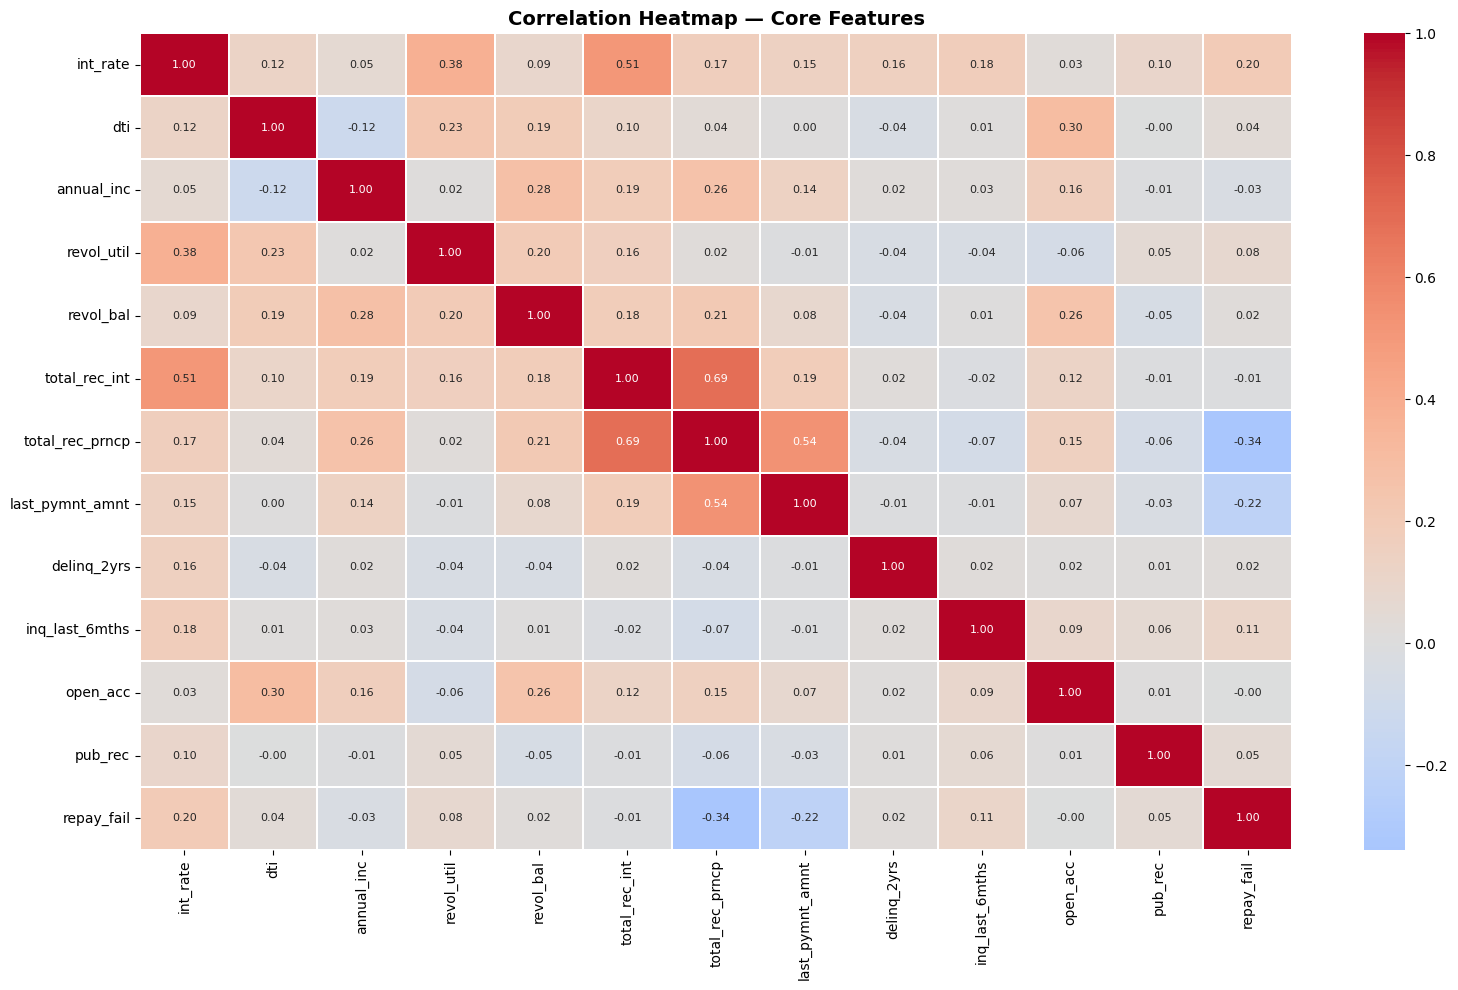

In [13]:
# Select core numeric features for readability
core_features = ['int_rate', 'dti', 'annual_inc', 'revol_util', 'revol_bal',
                 'total_rec_int', 'total_rec_prncp', 'last_pymnt_amnt',
                 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec',
                 'debt_to_income', 'installment_to_income', 'repayment_ratio',
                 'repay_fail']
 
# Only keep features that actually exist after all transformations
core_features = [f for f in core_features if f in df.columns]
 
corr_matrix = df[core_features].corr()
 
plt.figure(figsize=(16, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.3, annot_kws={'size': 8})
plt.title('Correlation Heatmap — Core Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

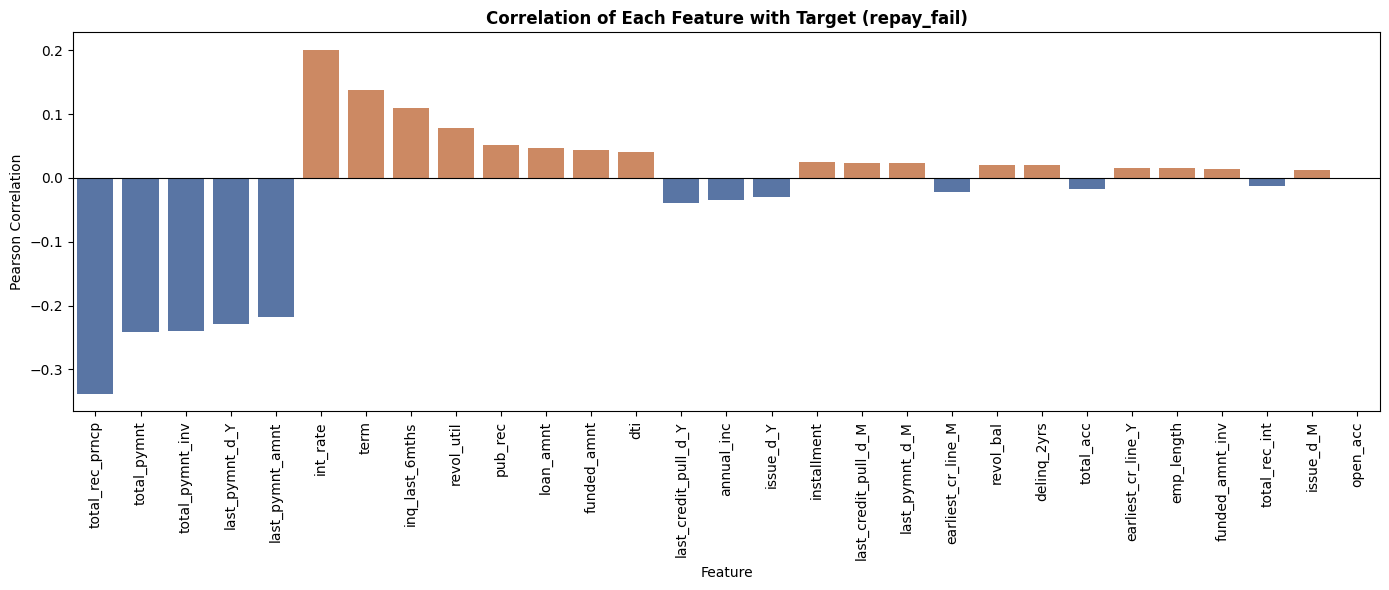


Top 10 features most correlated with default:
total_rec_prncp   -0.339021
total_pymnt       -0.242266
total_pymnt_inv   -0.240047
last_pymnt_d_Y    -0.229716
last_pymnt_amnt   -0.218075
int_rate           0.201051
term               0.137146
inq_last_6mths     0.109798
revol_util         0.078561
pub_rec            0.050733
dtype: float64


In [14]:
X_temp = df.drop('repay_fail', axis=1)
y_temp = df['repay_fail']
 
# Only numeric columns for corrwith
X_numeric = X_temp.select_dtypes(include=['number'])
correlations_with_target = X_numeric.corrwith(y_temp).sort_values(key=abs, ascending=False)
 
plt.figure(figsize=(14, 6))
colors = ['#DD8452' if v > 0 else '#4C72B0' for v in correlations_with_target.values]
sns.barplot(x=correlations_with_target.index,
            y=correlations_with_target.values,
            palette=colors)
plt.title('Correlation of Each Feature with Target (repay_fail)', fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Pearson Correlation')
plt.xticks(rotation=90)
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()
 
print("\nTop 10 features most correlated with default:")
print(correlations_with_target.head(10))

In [15]:
# Why ratios instead of raw values:
# A $500 installment means very different things for a $20k vs $100k earner
# Ratios capture repayment capacity — raw dollar values do not
 
df['debt_to_income']        = df['loan_amnt'] / (df['annual_inc'] + 1)
df['installment_to_income'] = df['installment'] / ((df['annual_inc'] / 12) + 1)
df['repayment_ratio']       = df['total_pymnt'] / (df['loan_amnt'] + 1)
 
print("New engineered features:")
print(df[['debt_to_income', 'installment_to_income', 'repayment_ratio']].describe())
 
# Now drop raw columns that the ratios replaced
df = df.drop(columns=[
    'loan_amnt',         # captured in debt_to_income
    'funded_amnt',       # duplicate of loan_amnt
    'funded_amnt_inv',   # similar to funded_amnt
    'installment',       # captured in installment_to_income
    'total_pymnt',       # captured in repayment_ratio
    'total_pymnt_inv',   # similar to total_pymnt
])
 
print("\nShape after feature engineering:", df.shape)

New engineered features:
       debt_to_income  installment_to_income  repayment_ratio
count    37359.000000           37359.000000     37359.000000
mean         0.185702               0.065443         1.083061
std          0.115468               0.039960         0.276285
min          0.000000               0.000000         0.000000
25%          0.098038               0.035094         1.070907
50%          0.162497               0.057547         1.144841
75%          0.249995               0.087832         1.218415
max          1.119776               0.434413         1.689084

Shape after feature engineering: (37359, 46)


In [16]:
numerical_columns = df.select_dtypes(include=['number']).columns.drop('repay_fail')
 
print("Shape before outlier clipping:", df.shape)
 
for col in numerical_columns:
    lo = df[col].quantile(0.01)
    hi = df[col].quantile(0.99)
    df[col] = df[col].clip(lo, hi)
 
print("Shape after outlier clipping:", df.shape)
print("(All rows kept — outlier values clipped to 1st/99th percentile bounds)")
print("Class distribution preserved:")
print(df['repay_fail'].value_counts())

Shape before outlier clipping: (37359, 46)
Shape after outlier clipping: (37359, 46)
(All rows kept — outlier values clipped to 1st/99th percentile bounds)
Class distribution preserved:
repay_fail
0    31834
1     5525
Name: count, dtype: int64


In [17]:
X = df.drop('repay_fail', axis=1)
y = df['repay_fail']
 
print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nData types in X (should be all numeric):")
print(X.dtypes.value_counts())
print("\nFeature names:")
print(X.columns.tolist())

Features shape: (37359, 45)
Target shape: (37359,)

Data types in X (should be all numeric):
float64    21
bool       19
int32       4
int64       1
Name: count, dtype: int64

Feature names:
['term', 'int_rate', 'emp_length', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'total_rec_prncp', 'total_rec_int', 'last_pymnt_amnt', 'earliest_cr_line_M', 'earliest_cr_line_Y', 'issue_d_M', 'issue_d_Y', 'last_pymnt_d_M', 'last_pymnt_d_Y', 'last_credit_pull_d_M', 'last_credit_pull_d_Y', 'home_ownership_NONE', 'home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT', 'verification_status_Source Verified', 'verification_status_Verified', 'purpose_credit_card', 'purpose_debt_consolidation', 'purpose_educational', 'purpose_home_improvement', 'purpose_house', 'purpose_major_purchase', 'purpose_medical', 'purpose_moving', 'purpose_other', 'purpose_renewable_energy', 'purpose_small_business', 'purpose_vacation', 'purpose_w

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
 
# stratify=y ensures same ~15% default rate in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
 
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Train default rate: {y_train.mean():.4%}")
print(f"Test default rate:  {y_test.mean():.4%}")
 
# Scale AFTER split — fit only on train, apply to both
# Fitting on all data before split leaks test distribution into the scaler
scaler = StandardScaler()
num_cols_to_scale = X_train.select_dtypes(include=['number']).columns
 
X_train = X_train.copy()
X_test  = X_test.copy()
 
X_train[num_cols_to_scale] = scaler.fit_transform(X_train[num_cols_to_scale])
X_test[num_cols_to_scale]  = scaler.transform(X_test[num_cols_to_scale])
 
print("\nScaling done. X_train sample:")
print(X_train.head(2))

Train: (29887, 45) | Test: (7472, 45)
Train default rate: 14.7890%
Test default rate:  14.7885%

Scaling done. X_train sample:
          term  int_rate  emp_length  annual_inc       dti  delinq_2yrs  \
3258 -0.587873 -0.325455   -0.318239    0.302669  1.282460     4.467868   
4167 -0.587873  0.302929    0.206402   -0.808012 -0.091454     4.467868   

      inq_last_6mths  open_acc   pub_rec  revol_bal  ...  purpose_medical  \
3258        0.679235  1.525465 -0.237673   0.105423  ...            False   
4167        2.125228  1.296098 -0.237673  -0.327029  ...            False   

      purpose_moving  purpose_other  purpose_renewable_energy  \
3258           False          False                     False   
4167           False          False                     False   

      purpose_small_business  purpose_vacation  purpose_wedding  \
3258                   False             False            False   
4167                   False             False            False   

      debt_to_inc

In [20]:
%pip install imblearn

Defaulting to user installation because normal site-packages is not writeable
  Using cached imblearn-0.0-py2.py3-none-any.whl.metadata (355 bytes)
  Using cached imbalanced_learn-0.14.1-py3-none-any.whl.metadata (8.9 kB)
  Using cached sklearn_compat-0.1.5-py3-none-any.whl.metadata (20 kB)
Using cached imblearn-0.0-py2.py3-none-any.whl (1.9 kB)
Using cached imbalanced_learn-0.14.1-py3-none-any.whl (235 kB)
Using cached sklearn_compat-0.1.5-py3-none-any.whl (20 kB)

   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ---------------------------------------- 3/3 [imblearn]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\TransOrg\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [21]:
from imblearn.over_sampling import SMOTE
 
# Your data: ~31,834 non-defaults vs ~5,525 defaults
# SMOTE generates synthetic minority (default) samples to balance training set
# NEVER apply SMOTE to test data — test must reflect real-world distribution
 
print("Before SMOTE:", y_train.value_counts().to_dict())
 
sm = SMOTE(random_state=42, k_neighbors=5)
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)
 
print("After SMOTE: ", pd.Series(y_train_bal).value_counts().to_dict())
print("Training set is now balanced for model learning")

Before SMOTE: {0: 25467, 1: 4420}
After SMOTE:  {0: 25467, 1: 25467}
Training set is now balanced for model learning


LR best params: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
LR best AUC:    0.9966


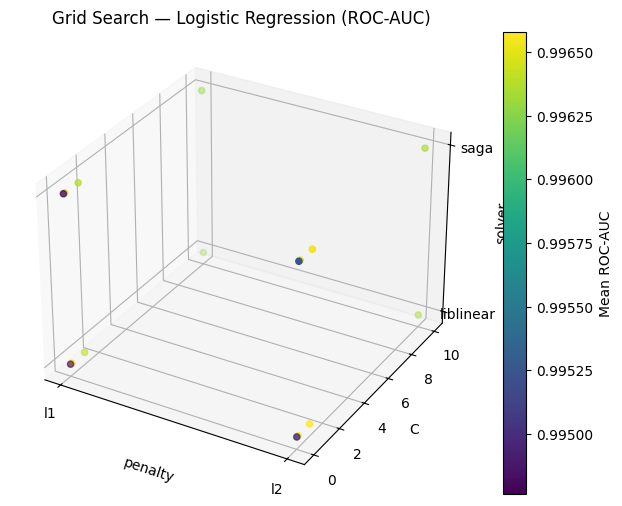


RF best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
RF best AUC:    0.9998


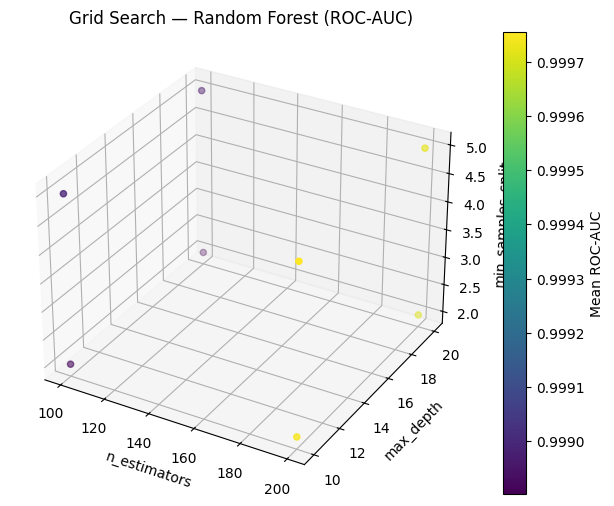


DT best params: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
DT best AUC:    0.9911


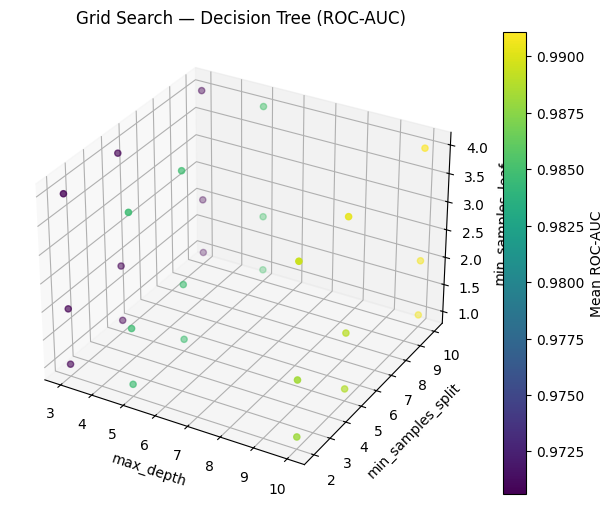

In [22]:
import itertools
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
 
# ── Logistic Regression GridSearch
param_grid_lr = {
    'penalty': ['l1', 'l2'],
    'C'      : [0.01, 0.1, 1, 10],
    'solver' : ['liblinear', 'saga']
}
 
gs_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid_lr,
    cv=5,
    scoring='roc_auc',   # FIXED from accuracy
    n_jobs=-1
)
gs_lr.fit(X_train_bal, y_train_bal)
print("LR best params:", gs_lr.best_params_)
print("LR best AUC:   ", round(gs_lr.best_score_, 4))
 
# 3D visualisation of LR grid search
from mpl_toolkits.mplot3d import Axes3D
penalty_map = {'l1': 0, 'l2': 1}
solver_map  = {'liblinear': 0, 'saga': 1}
num_penalty = [penalty_map[p] for p in gs_lr.cv_results_['param_penalty']]
num_solver  = [solver_map[s]  for s in gs_lr.cv_results_['param_solver']]
 
fig = plt.figure(figsize=(8, 6))
ax  = fig.add_subplot(111, projection='3d')
scatter = ax.scatter3D(num_penalty,
                       gs_lr.cv_results_['param_C'],
                       num_solver,
                       c=gs_lr.cv_results_['mean_test_score'],
                       cmap='viridis', marker='o')
ax.set_xlabel('penalty')
ax.set_ylabel('C')
ax.set_zlabel('solver')
ax.set_title('Grid Search — Logistic Regression (ROC-AUC)')
ax.set_xticks([0, 1]); ax.set_xticklabels(['l1', 'l2'])
ax.set_zticks([0, 1]); ax.set_zticklabels(['liblinear', 'saga'])
fig.colorbar(scatter, ax=ax, label='Mean ROC-AUC')
plt.show()
 
 
# ── Random Forest GridSearch
param_grid_rf = {
    'n_estimators'    : [100, 200],
    'max_depth'       : [10, None],
    'min_samples_split': [2, 5]
}
 
gs_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf,
    cv=5,
    scoring='roc_auc',   # FIXED from accuracy
    n_jobs=-1
)
gs_rf.fit(X_train_bal, y_train_bal)
print("\nRF best params:", gs_rf.best_params_)
print("RF best AUC:   ", round(gs_rf.best_score_, 4))
 
param_combos = list(itertools.product(
    param_grid_rf['n_estimators'],
    param_grid_rf['max_depth'],
    param_grid_rf['min_samples_split']
))
scores = gs_rf.cv_results_['mean_test_score']
x_v, y_v, z_v = zip(*[(a, b if b is not None else 20, c) for a, b, c in param_combos])
 
fig = plt.figure(figsize=(8, 6))
ax  = fig.add_subplot(111, projection='3d')
scatter = ax.scatter3D(x_v, y_v, z_v, c=scores, cmap='viridis', marker='o')
ax.set_xlabel('n_estimators')
ax.set_ylabel('max_depth')
ax.set_zlabel('min_samples_split')
ax.set_title('Grid Search — Random Forest (ROC-AUC)')
fig.colorbar(scatter, ax=ax, label='Mean ROC-AUC')
plt.show()
 
 
# ── Decision Tree GridSearch
param_grid_dt = {
    'max_depth'       : [3, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
 
gs_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring='roc_auc',   # FIXED from accuracy
    n_jobs=-1
)
gs_dt.fit(X_train_bal, y_train_bal)
print("\nDT best params:", gs_dt.best_params_)
print("DT best AUC:   ", round(gs_dt.best_score_, 4))
 
param_combos_dt = list(itertools.product(
    param_grid_dt['max_depth'],
    param_grid_dt['min_samples_split'],
    param_grid_dt['min_samples_leaf']
))
scores_dt = gs_dt.cv_results_['mean_test_score']
x_v, y_v, z_v = zip(*param_combos_dt)
 
fig = plt.figure(figsize=(8, 6))
ax  = fig.add_subplot(111, projection='3d')
scatter = ax.scatter3D(x_v, y_v, z_v, c=scores_dt, cmap='viridis', marker='o')
ax.set_xlabel('max_depth')
ax.set_ylabel('min_samples_split')
ax.set_zlabel('min_samples_leaf')
ax.set_title('Grid Search — Decision Tree (ROC-AUC)')
fig.colorbar(scatter, ax=ax, label='Mean ROC-AUC')
plt.show()
 

In [24]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_auc_score,
                              roc_curve, precision_recall_curve, auc,
                              classification_report, log_loss)
 
# scale_pos_weight = non-defaults / defaults = ~5.76
# Tells XGBoost to penalise missing a default 5.76x more than a false alarm
scale_pos_weight = float((y_train == 0).sum() / (y_train == 1).sum())
 
models = {
    'Logistic Regression': LogisticRegression(
        **gs_lr.best_params_, max_iter=1000, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        **gs_rf.best_params_, random_state=42, n_jobs=-1
    ),
    'Decision Tree': DecisionTreeClassifier(
        **gs_dt.best_params_, random_state=42
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        scale_pos_weight=scale_pos_weight,
        eval_metric='auc',
        random_state=42,
        verbosity=0
    )
}
 
results = {}
 
print(f"{'Model':<25} {'ROC-AUC':>8} {'Precision':>10} {'Recall':>8} {'F1':>8} {'Accuracy':>10}")
print("-" * 75)
 
for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
 
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc_roc = roc_auc_score(y_test, y_prob)
 
    results[name] = {
        'model'    : model,
        'y_pred'   : y_pred,
        'y_prob'   : y_prob,
        'roc_auc'  : auc_roc,
        'precision': prec,
        'recall'   : rec,
        'f1'       : f1,
        'accuracy' : acc
    }
 
    print(f"{name:<25} {auc_roc:>8.4f} {prec:>10.4f} {rec:>8.4f} {f1:>8.4f} {acc:>10.4f}")
 
print("\nFull classification report for XGBoost:")
print(classification_report(y_test, results['XGBoost']['y_pred'],
                             target_names=['Non-Default', 'Default']))

Model                      ROC-AUC  Precision   Recall       F1   Accuracy
---------------------------------------------------------------------------
Logistic Regression         0.9920     0.9093   0.9339   0.9214     0.9764
Random Forest               0.9970     0.9705   0.9231   0.9462     0.9845
Decision Tree               0.9827     0.9225   0.9593   0.9406     0.9821
XGBoost                     0.9981     0.9636   0.9810   0.9722     0.9917

Full classification report for XGBoost:
              precision    recall  f1-score   support

 Non-Default       1.00      0.99      1.00      6367
     Default       0.96      0.98      0.97      1105

    accuracy                           0.99      7472
   macro avg       0.98      0.99      0.98      7472
weighted avg       0.99      0.99      0.99      7472



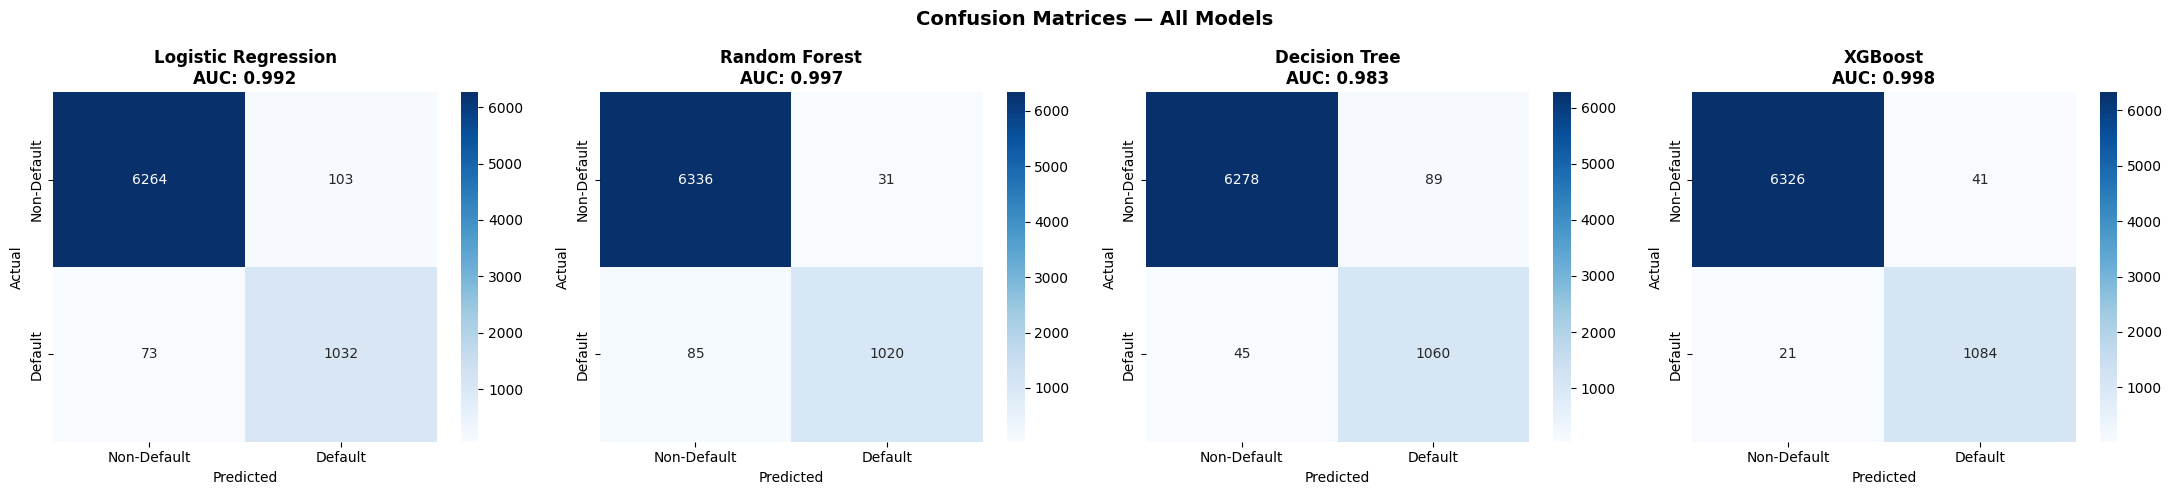

In [25]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
 
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-Default', 'Default'],
                yticklabels=['Non-Default', 'Default'])
    ax.set_title(f"{name}\nAUC: {res['roc_auc']:.3f}", fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
 
plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

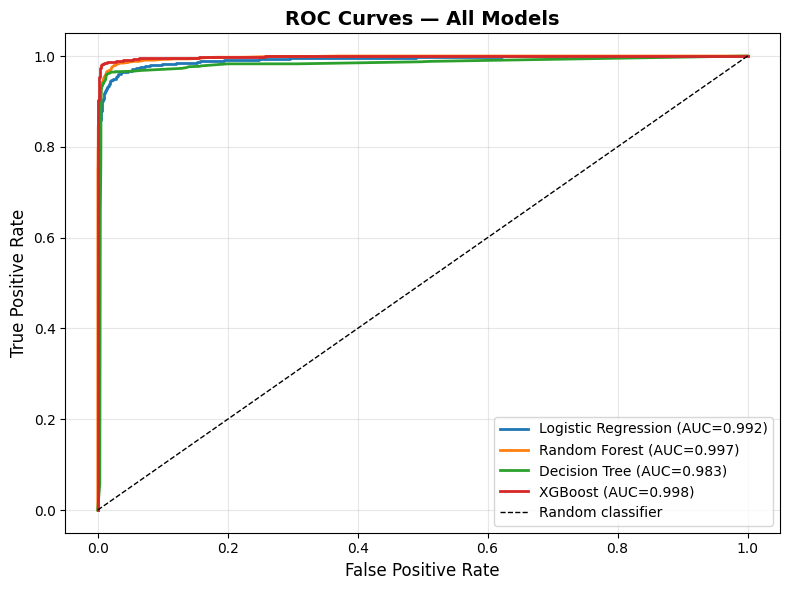

In [26]:
plt.figure(figsize=(8, 6))
 
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    plt.plot(fpr, tpr,
             label=f"{name} (AUC={res['roc_auc']:.3f})",
             linewidth=2)
 
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
 

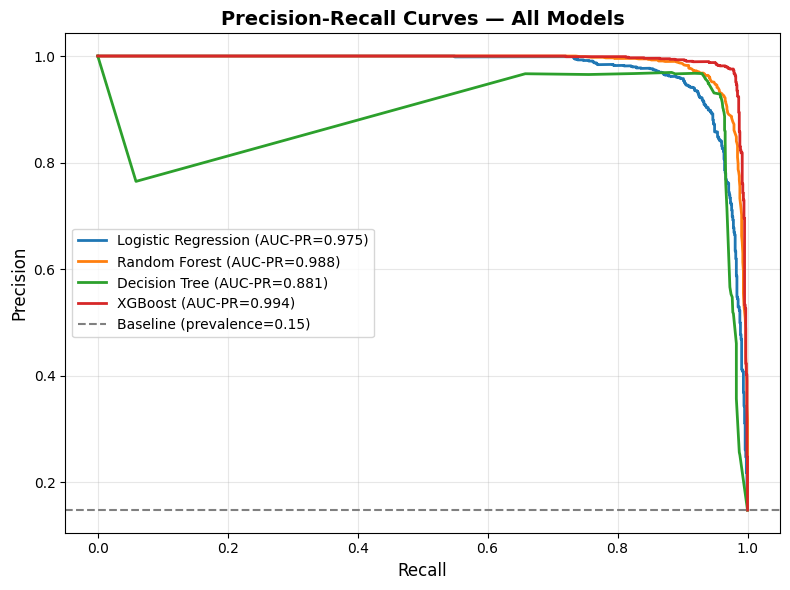

In [27]:
plt.figure(figsize=(8, 6))
 
for name, res in results.items():
    prec_curve, rec_curve, _ = precision_recall_curve(y_test, res['y_prob'])
    auc_pr = auc(rec_curve, prec_curve)
    plt.plot(rec_curve, prec_curve,
             label=f"{name} (AUC-PR={auc_pr:.3f})",
             linewidth=2)
 
# Baseline = random classifier at class prevalence rate
baseline = y_test.mean()
plt.axhline(baseline, color='gray', linestyle='--',
            label=f'Baseline (prevalence={baseline:.2f})')
 
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Logistic Regression       | Train log-loss: 0.0623 | Test log-loss: 0.0799
Random Forest             | Train log-loss: 0.0159 | Test log-loss: 0.0684
Decision Tree             | Train log-loss: 0.0382 | Test log-loss: 0.2119
XGBoost                   | Train log-loss: 0.0153 | Test log-loss: 0.0399


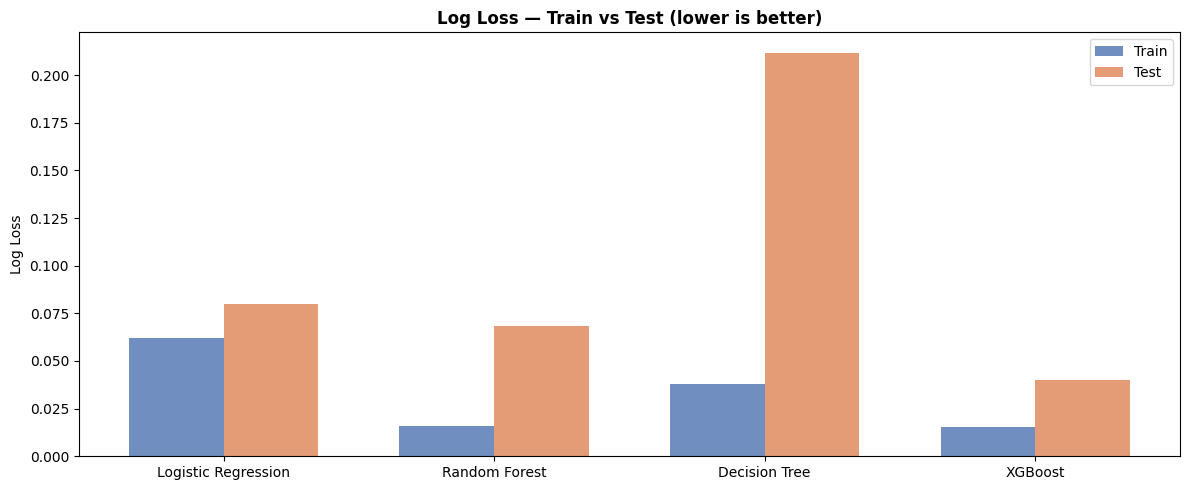

In [28]:
plt.figure(figsize=(12, 5))
 
model_names = []
train_losses = []
test_losses  = []
 
for name, res in results.items():
    train_prob = res['model'].predict_proba(X_train_bal)[:, 1]
    test_prob  = res['y_prob']
 
    ll_train = log_loss(y_train_bal, train_prob)
    ll_test  = log_loss(y_test, test_prob)
 
    model_names.append(name)
    train_losses.append(ll_train)
    test_losses.append(ll_test)
 
    print(f"{name:<25} | Train log-loss: {ll_train:.4f} | Test log-loss: {ll_test:.4f}")
 
x = np.arange(len(model_names))
width = 0.35
 
plt.bar(x - width/2, train_losses, width, label='Train', color='#4C72B0', alpha=0.8)
plt.bar(x + width/2, test_losses,  width, label='Test',  color='#DD8452', alpha=0.8)
plt.xticks(x, model_names)
plt.ylabel('Log Loss')
plt.title('Log Loss — Train vs Test (lower is better)', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
# Soft voting averages predicted probabilities across all models
# More reliable than hard voting (majority of binary predictions)
 
all_probs = np.array([res['y_prob'] for res in results.values()])
ensemble_probs = all_probs.mean(axis=0)
ensemble_preds = (ensemble_probs >= 0.5).astype(int)
 
ens_auc = roc_auc_score(y_test, ensemble_probs)
ens_f1  = f1_score(y_test, ensemble_preds)
ens_rec = recall_score(y_test, ensemble_preds)
 
print("Ensemble (Soft Voting) Results:")
print(f"  ROC-AUC : {ens_auc:.4f}")
print(f"  F1      : {ens_f1:.4f}")
print(f"  Recall  : {ens_rec:.4f}")
print(classification_report(y_test, ensemble_preds,
                             target_names=['Non-Default', 'Default']))

Ensemble (Soft Voting) Results:
  ROC-AUC : 0.9978
  F1      : 0.9705
  Recall  : 0.9683
              precision    recall  f1-score   support

 Non-Default       0.99      1.00      0.99      6367
     Default       0.97      0.97      0.97      1105

    accuracy                           0.99      7472
   macro avg       0.98      0.98      0.98      7472
weighted avg       0.99      0.99      0.99      7472



In [31]:
%pip install shap

Defaulting to user installation because normal site-packages is not writeable
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached numba-0.64.0-cp313-cp313-win_amd64.whl.metadata (3.0 kB)
  Using cached llvmlite-0.46.0-cp313-cp313-win_amd64.whl.metadata (5.1 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ------------------ --------------------- 262.1/555.9 kB ? eta -:--:--
   ---------------------------------------- 555.9/555.9 kB 1.3 MB/s  0:00:00
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)
Using cached llvmlite-0.46.0-cp313-cp313-win_amd64.whl (38.1 MB)
Using cached numba-0.64.0-cp313-cp313-win_amd64.whl (2.8 MB)
Using cached typing_extensions-4.15.0-py3-none-any.whl (44 kB)

   ----------------- ---------------------- 3/7 [llvmlite]
   ----------------- ---------------------- 3/7 


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\TransOrg\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Generating SHAP global summary plot...


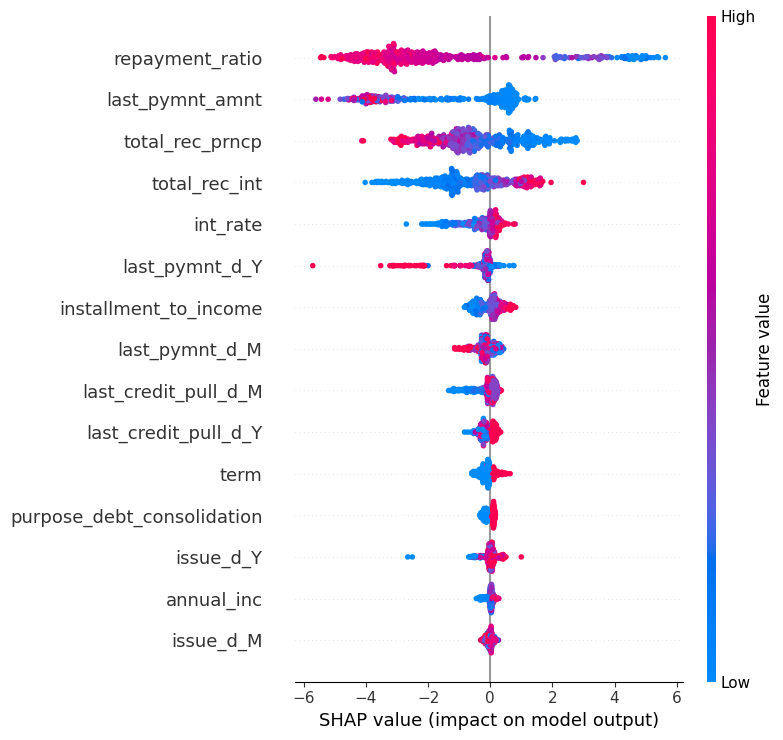

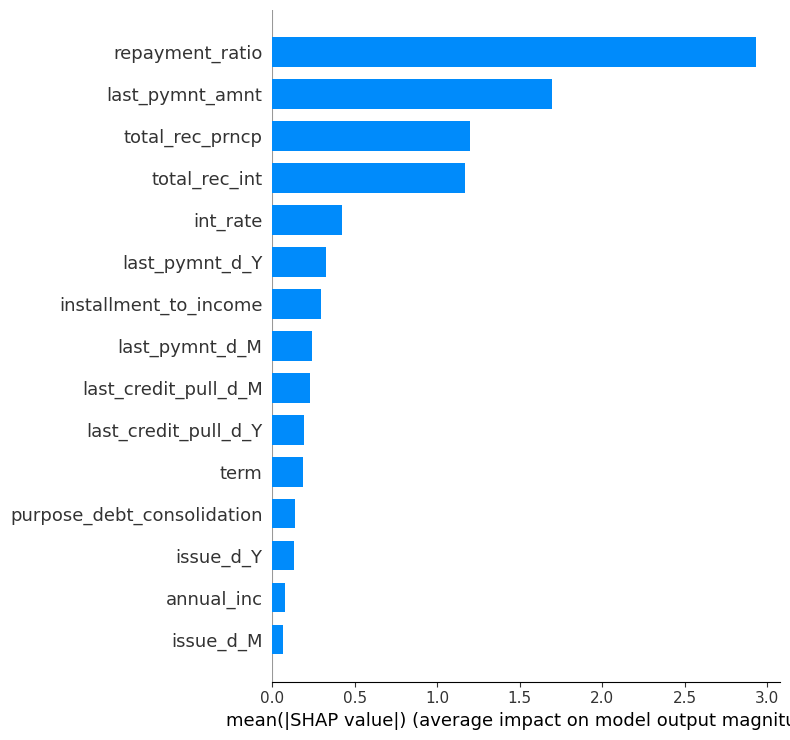


Explaining prediction for test sample 4 (actual default):
  Predicted probability: 0.9999
  True label: 1


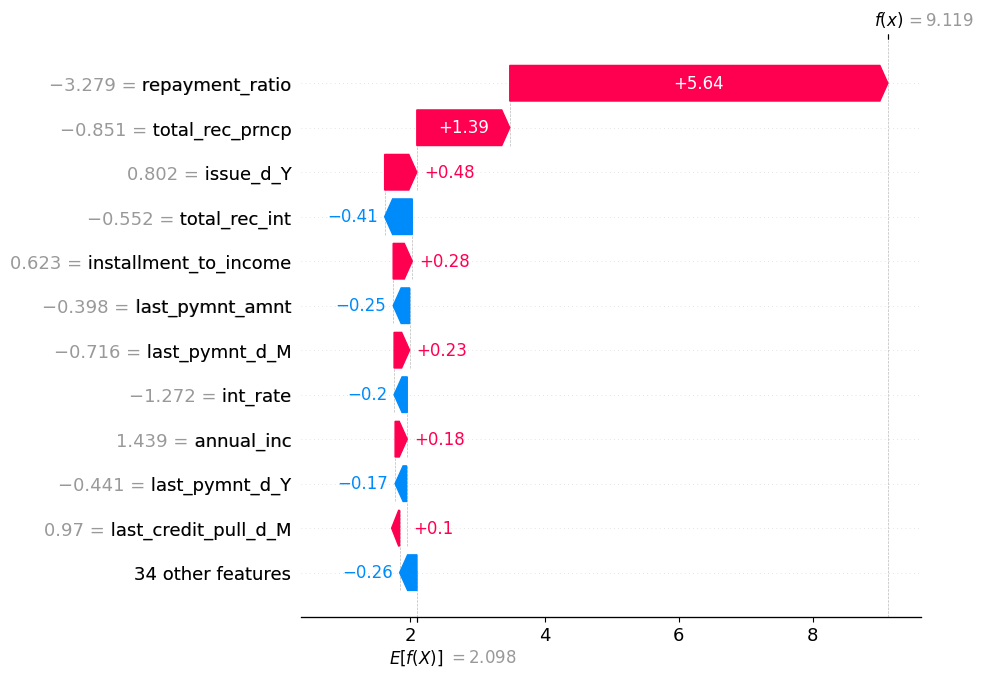


Top 5 features pushing toward default for this borrower:
  repayment_ratio                SHAP: +5.6379  → DEFAULT
  total_rec_prncp                SHAP: +1.3858  → DEFAULT
  issue_d_Y                      SHAP: +0.4797  → DEFAULT
  total_rec_int                  SHAP: -0.4120  → NON-DEFAULT
  installment_to_income          SHAP: +0.2848  → DEFAULT


In [32]:
import shap
 
xgb_model = results['XGBoost']['model']
 
# TreeExplainer is fast and exact for XGBoost — no approximation needed
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test.iloc[:500])
 
# ── Global explanation: which features drive defaults most overall?
print("Generating SHAP global summary plot...")
shap.summary_plot(shap_values, X_test.iloc[:500],
                  feature_names=X_test.columns.tolist(),
                  max_display=15,
                  show=True)
 
# ── Global bar chart: mean absolute SHAP values
shap.summary_plot(shap_values, X_test.iloc[:500],
                  feature_names=X_test.columns.tolist(),
                  plot_type='bar',
                  max_display=15,
                  show=True)
 
# ── Local explanation: explain one actual default prediction
default_positions = (y_test.values == 1).nonzero()[0]
idx = default_positions[0]
 
print(f"\nExplaining prediction for test sample {idx} (actual default):")
print(f"  Predicted probability: {results['XGBoost']['y_prob'][idx]:.4f}")
print(f"  True label: {y_test.values[idx]}")
 
shap.plots.waterfall(shap.Explanation(
    values        = shap_values[idx],
    base_values   = explainer.expected_value,
    data          = X_test.iloc[idx].values,
    feature_names = X_test.columns.tolist()
), max_display=12)
 
print("\nTop 5 features pushing toward default for this borrower:")
shap_dict = dict(zip(X_test.columns, shap_values[idx]))
top5 = sorted(shap_dict.items(), key=lambda x: abs(x[1]), reverse=True)[:5]
for feat, val in top5:
    direction = '→ DEFAULT' if val > 0 else '→ NON-DEFAULT'
    print(f"  {feat:<30} SHAP: {val:+.4f}  {direction}")

── Business Cost Analysis ──────────────────────────────
  Baseline cost (no model, approve all): $ 5,525,000
  Cost at default threshold 0.50:        $   113,200
  Cost at optimal threshold 0.31:        $    93,200
  Savings vs baseline:                   $ 5,431,800
  Savings vs default threshold:          $    20,000
────────────────────────────────────────────────────────


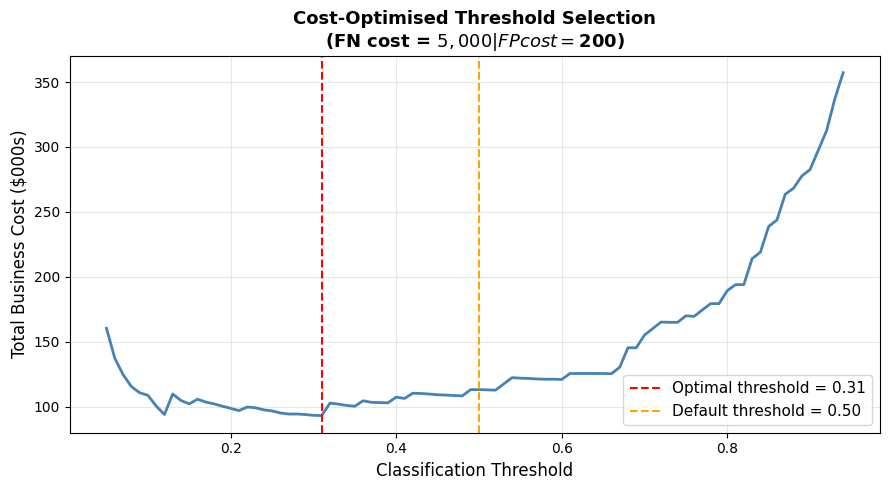


Confusion matrix at optimal threshold (0.31):
[[6276   91]
 [  15 1090]]
              precision    recall  f1-score   support

 Non-Default       1.00      0.99      0.99      6367
     Default       0.92      0.99      0.95      1105

    accuracy                           0.99      7472
   macro avg       0.96      0.99      0.97      7472
weighted avg       0.99      0.99      0.99      7472



In [33]:
# Business framing for loan default:
# False Negative (missed default)  = bank absorbs full loan loss ~ $5,000
# False Positive (rejected good borrower) = lost interest revenue ~ $200
#
# Default threshold of 0.5 is NOT optimal for this cost structure
# We sweep thresholds to find the point that minimises total business cost
 
xgb_probs = results['XGBoost']['y_prob']
 
FN_COST = 5000   # cost of missing a default
FP_COST = 200    # cost of wrongly rejecting a good borrower
 
thresholds = np.arange(0.05, 0.95, 0.01)
costs      = []
 
for t in thresholds:
    preds          = (xgb_probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    total_cost     = (fn * FN_COST) + (fp * FP_COST)
    costs.append(total_cost)
 
best_threshold = thresholds[np.argmin(costs)]
best_cost      = min(costs)
baseline_cost  = int(y_test.sum()) * FN_COST  # cost if we approved everyone
 
# Default 0.5 threshold cost
preds_default  = (xgb_probs >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, preds_default).ravel()
default_cost   = (fn * FN_COST) + (fp * FP_COST)
 
print("── Business Cost Analysis ──────────────────────────────")
print(f"  Baseline cost (no model, approve all): ${baseline_cost:>10,.0f}")
print(f"  Cost at default threshold 0.50:        ${default_cost:>10,.0f}")
print(f"  Cost at optimal threshold {best_threshold:.2f}:        ${best_cost:>10,.0f}")
print(f"  Savings vs baseline:                   ${baseline_cost - best_cost:>10,.0f}")
print(f"  Savings vs default threshold:          ${default_cost - best_cost:>10,.0f}")
print("────────────────────────────────────────────────────────")
 
plt.figure(figsize=(9, 5))
plt.plot(thresholds, [c/1000 for c in costs], linewidth=2, color='steelblue')
plt.axvline(best_threshold, color='red', linestyle='--',
            label=f'Optimal threshold = {best_threshold:.2f}')
plt.axvline(0.5, color='orange', linestyle='--',
            label='Default threshold = 0.50')
plt.xlabel('Classification Threshold', fontsize=12)
plt.ylabel('Total Business Cost ($000s)', fontsize=12)
plt.title('Cost-Optimised Threshold Selection\n(FN cost = $5,000 | FP cost = $200)',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
 
# Show confusion matrix at optimal threshold
preds_optimal  = (xgb_probs >= best_threshold).astype(int)
print(f"\nConfusion matrix at optimal threshold ({best_threshold:.2f}):")
print(confusion_matrix(y_test, preds_optimal))
print(classification_report(y_test, preds_optimal,
                             target_names=['Non-Default', 'Default']))

In [35]:
%pip install mlflow

Defaulting to user installation because normal site-packages is not writeable
  Using cached docker-7.1.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached pandas-2.3.3-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached click-8.3.1-py3-none-any.whl.metadata (2.6 kB)
  Using cached pydantic-2.12.5-py3-none-any.whl.metadata (90 kB)
  Using cached pyyaml-6.0.3-cp313-cp313-win_amd64.whl.metadata (2.4 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached cffi-2.0.0-cp313-cp313-win_amd64.whl.metadata (2.6 kB)
  Using cached pywin32-311-cp313-cp313-win_amd64.whl.metadata (10 kB)
  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached markupsafe-3.0.3-cp313-cp313-win_amd64.whl.metadata (2.8 kB)
  Using cached gitdb-4.0.12-py3-none

  You can safely remove it manually.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\TransOrg\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [36]:
import mlflow
import mlflow.sklearn
 
mlflow.set_experiment("loan-default-prediction")
 
xgb_preds_optimal = (xgb_probs >= best_threshold).astype(int)
 
with mlflow.start_run(run_name="xgboost-cost-optimised"):
 
    mlflow.log_params({
        "model"              : "XGBoost",
        "n_estimators"       : 200,
        "max_depth"          : 6,
        "learning_rate"      : 0.05,
        "scale_pos_weight"   : round(scale_pos_weight, 2),
        "imbalance_handling" : "SMOTE + scale_pos_weight",
        "optimal_threshold"  : round(float(best_threshold), 2),
        "fn_cost"            : FN_COST,
        "fp_cost"            : FP_COST
    })
 
    mlflow.log_metrics({
        "roc_auc"            : round(float(roc_auc_score(y_test, xgb_probs)), 4),
        "f1_default_class"   : round(float(f1_score(y_test, xgb_preds_optimal)), 4),
        "recall_default"     : round(float(recall_score(y_test, xgb_preds_optimal)), 4),
        "precision_default"  : round(float(precision_score(y_test, xgb_preds_optimal,
                                                             zero_division=0)), 4),
        "business_cost_usd"  : int(best_cost),
        "cost_savings_usd"   : int(baseline_cost - best_cost)
    })
 
    mlflow.sklearn.log_model(xgb_model, "xgboost_loan_default_model")
 
print("MLflow run logged.")
print("Run 'mlflow ui' in your terminal to view the experiment dashboard.")
print("Screenshot the dashboard and add it to your README.")
 

2026/03/25 11:42:49 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/25 11:42:49 INFO mlflow.store.db.utils: Updating database tables
2026/03/25 11:42:50 INFO mlflow.tracking.fluent: Experiment with name 'loan-default-prediction' does not exist. Creating a new experiment.
2026/03/25 11:42:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/25 11:42:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


MLflow run logged.
Run 'mlflow ui' in your terminal to view the experiment dashboard.
Screenshot the dashboard and add it to your README.


In [37]:
import joblib
import os
 
os.makedirs('models', exist_ok=True)
 
joblib.dump(xgb_model, 'models/xgboost_model.pkl')
joblib.dump(scaler,    'models/scaler.pkl')
joblib.dump(explainer, 'models/shap_explainer.pkl')
joblib.dump(X_train.columns.tolist(), 'models/feature_names.pkl')
joblib.dump(best_threshold, 'models/optimal_threshold.pkl')
 
print("Saved artifacts:")
print("  models/xgboost_model.pkl")
print("  models/scaler.pkl")
print("  models/shap_explainer.pkl")
print("  models/feature_names.pkl")
print("  models/optimal_threshold.pkl")
print()
print("Next steps:")
print("  1. Run FastAPI:   uvicorn api.main:app --host 0.0.0.0 --port 8000")
print("  2. Run Streamlit: streamlit run frontend/app.py")
print("  3. View MLflow:   mlflow ui")
 

Saved artifacts:
  models/xgboost_model.pkl
  models/scaler.pkl
  models/shap_explainer.pkl
  models/feature_names.pkl
  models/optimal_threshold.pkl

Next steps:
  1. Run FastAPI:   uvicorn api.main:app --host 0.0.0.0 --port 8000
  2. Run Streamlit: streamlit run frontend/app.py
  3. View MLflow:   mlflow ui


In [38]:
%pip install mlflow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\TransOrg\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
